In [ ]:
# Этап 1 Загрузка и первичное знакомство

import scipy.io as sio
import pandas as pd
import numpy as np
from google.colab import files

# Список для хранения данных
file_paths = []
classes = [
    'Норма',
    'Дефект внутреннего кольца',
    'Дефект шарика',
    'Дефект внешнего кольца (Centered)',
    'Дефект внешнего кольца (Orthogonal)'
]

# Загрузка 5 файлов
print("Загрузите 5 файлов в следующем порядке:")
for i, cls in enumerate(classes, 1):
    print(f"{i}. {cls}")
for i in range(5):
    print(f"\n--- Загрузите файл {i+1} ---")
    uploaded = files.upload()
    file_paths.append(list(uploaded.keys())[0])

print("ПОДРОБНЫЙ АНАЛИЗ КАЖДОГО ФАЙЛА")

signals = []
signal_keys = []

for idx, (file, cls) in enumerate(zip(file_paths, classes)):
    print(f"\n--- {cls} ---")
    print(f"Файл: {file}")

    mat = sio.loadmat(file)

    all_keys = [k for k in mat.keys() if not k.startswith('__')]
    print(f"Ключи в файле: {all_keys}")

    signal_key = None
    for key in all_keys:
        obj = mat[key]
        if isinstance(obj, np.ndarray) and obj.ndim == 2 and obj.shape[1] == 1:
            if 'DE_time' in key or ('X' in key and 'DE' in key):
                signal_key = key
                break
    if signal_key is None:
        for key in all_keys:
            obj = mat[key]
            if isinstance(obj, np.ndarray) and obj.size > 1000:
                signal_key = key
                break

    signal = mat[signal_key].flatten()
    signals.append(signal)
    signal_keys.append(signal_key)

    # Первые 20 значений сигнала
    print(f"\n--- ПЕРВЫЕ 20 ЗНАЧЕНИЙ СИГНАЛА (ключ '{signal_key}') ---")
    print(signal[:20])

    # Общая информация о данных
    print("\n--- ОБЩАЯ ИНФОРМАЦИЯ ---")
    print(f"Количество каналов: 1 (одномерный временной ряд)")
    print(f"Длина ряда: {len(signal)} отсчётов")
    print(f"Тип данных: {signal.dtype}")
    print(f"Размерность массива: {signal.shape}")

    # Краткая статистика
    print("\n--- СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ (предварительные) ---")
    print(f"  min = {signal.min():.6f}")
    print(f"  max = {signal.max():.6f}")
    print(f"  mean = {signal.mean():.6f}")
    print(f"  std  = {signal.std():.6f}")

    # Проверка на пропуски
    if np.isnan(signal).any():
        print(f"\nПредупреждение: в сигнале есть пропуски (NaN). Количество: {np.isnan(signal).sum()}")
    else:
        print("\nПропуски (NaN) отсутствуют.")

# Сводная таблица по всем пяти файлам
print("СВОДНАЯ ТАБЛИЦА ПО 5 ФАЙЛАМ")

summary_data = []
for cls, file, key, sig in zip(classes, file_paths, signal_keys, signals):
    summary_data.append({
        'Класс': cls,
        'Файл': file,
        'Ключ сигнала': key,
        'Длина ряда': len(sig),
        'Тип данных': str(sig.dtype),
        'Пропуски': 0,
        'Временная метка': 'отсутствует'
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

Библиотеки импортированы

Загрузите 5 файлов в следующем порядке:
1. Норма
2. Дефект внутреннего кольца
3. Дефект шарика
4. Дефект внешнего кольца (Centered)
5. Дефект внешнего кольца (Orthogonal)

--- Загрузите файл 1 ---


Saving 97.mat to 97 (1).mat

--- Загрузите файл 2 ---


Saving 105.mat to 105 (1).mat

--- Загрузите файл 3 ---


Saving 118.mat to 118 (1).mat

--- Загрузите файл 4 ---


Saving 130.mat to 130 (1).mat

--- Загрузите файл 5 ---


Saving 144.mat to 144 (1).mat

ПОДРОБНЫЙ АНАЛИЗ КАЖДОГО ФАЙЛА

--- Норма ---
Файл: 97 (1).mat
Ключи в файле: ['X097_DE_time', 'X097_FE_time', 'X097RPM']

--- ПЕРВЫЕ 20 ЗНАЧЕНИЙ СИГНАЛА (ключ 'X097_DE_time') ---
[ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954 -0.056952
 -0.07176369 -0.05862092 -0.04652123 -0.04985908 -0.05111077 -0.01564615
  0.04589538  0.092208    0.09179077  0.06049846  0.024408   -0.00020862
  0.01752369  0.02628554]

--- ОБЩАЯ ИНФОРМАЦИЯ ---
Количество каналов: 1 (одномерный временной ряд)
Длина ряда: 243938 отсчётов
Тип данных: float64
Размерность массива: (243938,)

--- СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ (предварительные) ---
  min = -0.286638
  max = 0.311254
  mean = 0.012558
  std  = 0.072687

Пропуски (NaN) отсутствуют.

--- Дефект внутреннего кольца ---
Файл: 105 (1).mat
Ключи в файле: ['X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM']

--- ПЕРВЫЕ 20 ЗНАЧЕНИЙ СИГНАЛА (ключ 'X105_DE_time') ---
[-0.08300435 -0.19573433  0.23341928  0.10395848 

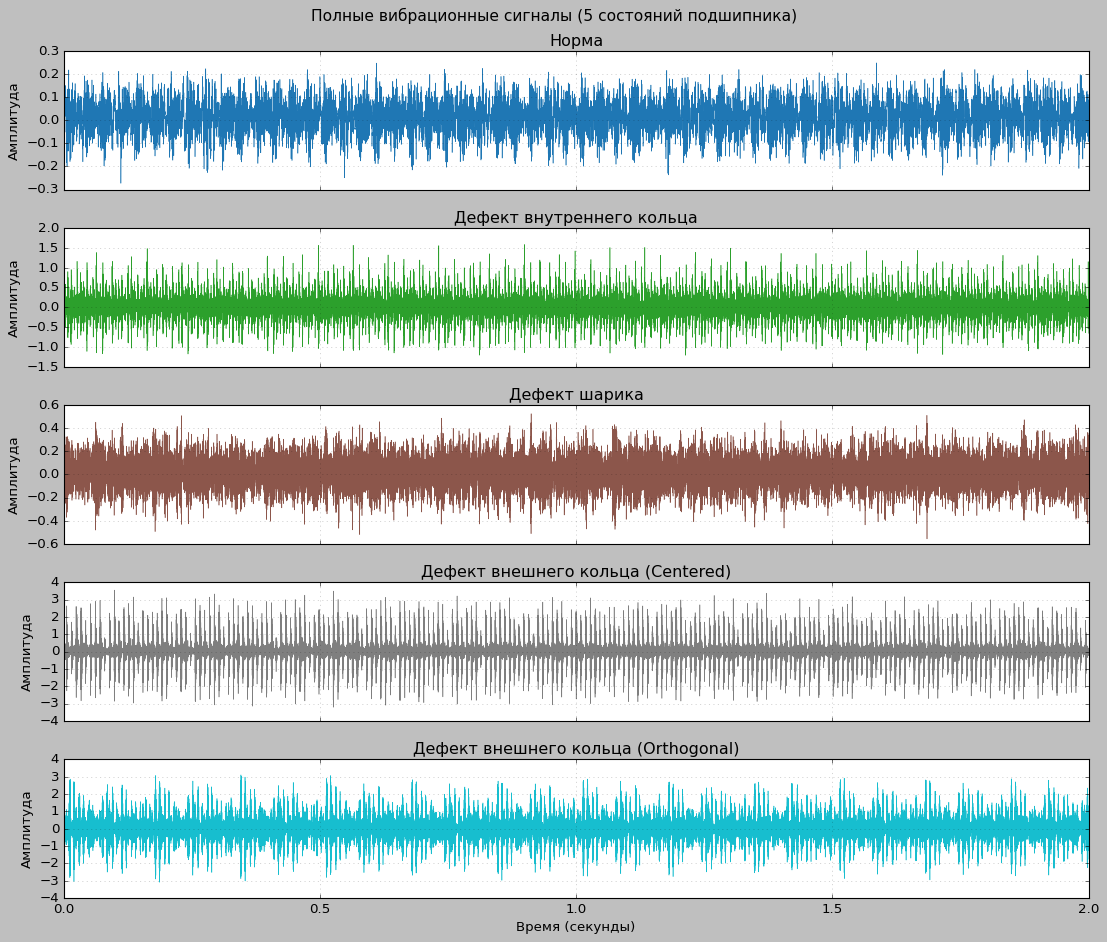

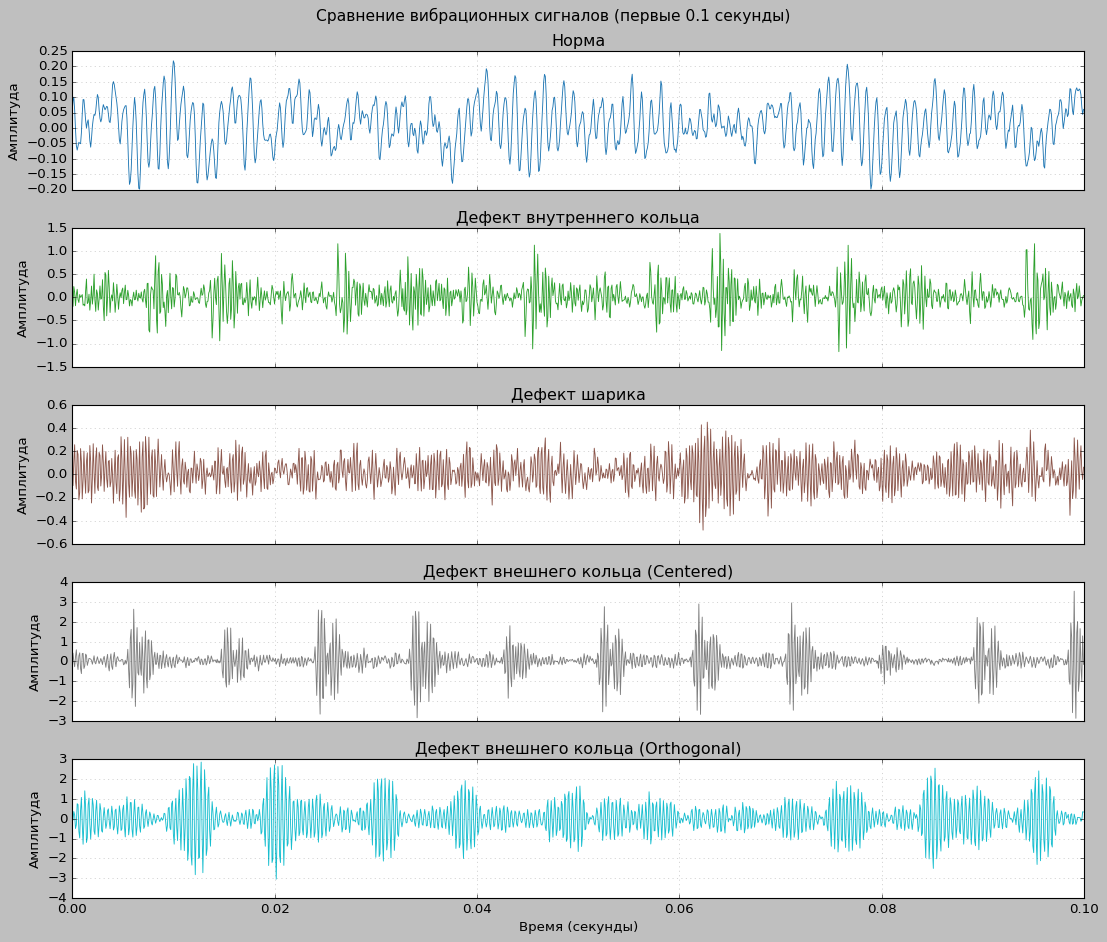

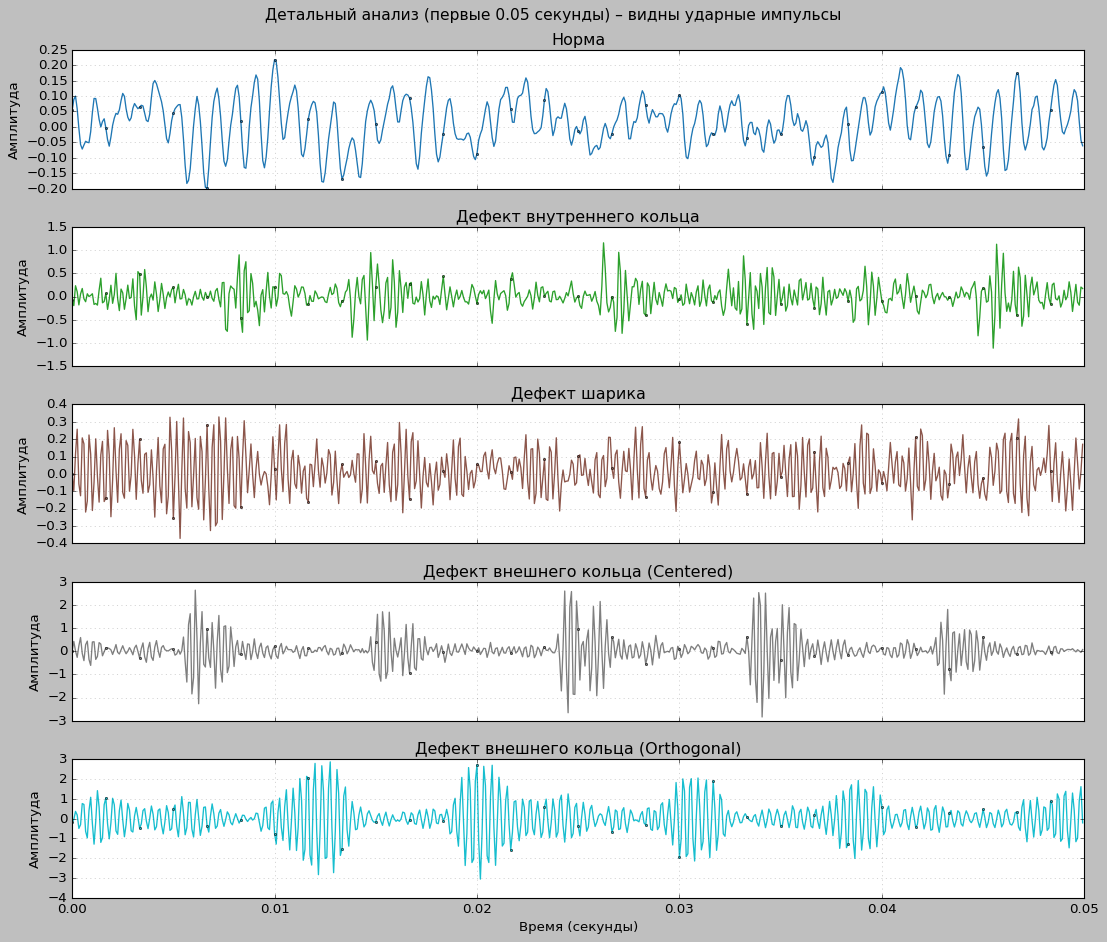

Визуализация завершена. Каждый сигнал имеет свой цвет.


In [ ]:
# Этап 2. Визуализация исходных данных

import matplotlib.pyplot as plt
import numpy as np

fs = 12000

time_arrays = [np.arange(len(sig)) / fs for sig in signals]

plt.style.use('classic')
plt.rcParams['figure.figsize'] = (14, 10)

colors = plt.cm.tab10(np.linspace(0, 1, 5))

# 1. Полные сигналы
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(14, 12))
fig.suptitle('Полные вибрационные сигналы (5 состояний подшипника)', fontsize=14)

for i, (sig, name, time) in enumerate(zip(signals, classes, time_arrays)):
    duration = min(2.0, len(sig)/fs)
    samples = int(duration * fs)
    axes[i].plot(time[:samples], sig[:samples], linewidth=0.5, color=colors[i])
    axes[i].set_ylabel('Амплитуда')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Время (секунды)')
plt.tight_layout()
plt.show()

# 2. Фрагменты сигналов (первые 0.1 секунды)
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(14, 12))
fig.suptitle('Сравнение вибрационных сигналов (первые 0.1 секунды)', fontsize=14)

duration_short = 0.1
samples_short = int(duration_short * fs)

for i, (sig, name, time) in enumerate(zip(signals, classes, time_arrays)):
    axes[i].plot(time[:samples_short], sig[:samples_short], linewidth=0.8, color=colors[i])
    axes[i].set_ylabel('Амплитуда')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Время (секунды)')
plt.tight_layout()
plt.show()

# 3. Детальный анализ (первые 0.05 секунды)
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(14, 12))
fig.suptitle('Детальный анализ (первые 0.05 секунды) – видны ударные импульсы', fontsize=14)

duration_detailed = 0.05
samples_detailed = int(duration_detailed * fs)

for i, (sig, name, time) in enumerate(zip(signals, classes, time_arrays)):
    axes[i].plot(time[:samples_detailed], sig[:samples_detailed],
                 linewidth=1.2, color=colors[i], marker='o', markersize=2, markevery=20)
    axes[i].set_ylabel('Амплитуда')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Время (секунды)')
plt.tight_layout()
plt.show()

In [ ]:
# Этап 3. Статистический анализ

import numpy as np
import pandas as pd
from scipy import stats

fs = 12000

# Функция для расчёта статистик
def compute_stats(signal):
    q1 = np.percentile(signal, 25)
    q2 = np.percentile(signal, 50)
    q3 = np.percentile(signal, 75)
    skewness = stats.skew(signal)
    kurt = stats.kurtosis(signal)
    return {
        'count': len(signal),
        'mean': np.mean(signal),
        'std': np.std(signal),
        'min': np.min(signal),
        'q1': q1,
        'median': q2,
        'q3': q3,
        'max': np.max(signal),
        'skewness': skewness,
        'kurtosis': kurt
    }

stats_list = []
for name, sig in zip(classes, signals):
    stats_list.append(compute_stats(sig))

df_stats = pd.DataFrame(stats_list)
df_stats.index = classes
df_stats = df_stats.round(6)

print("\nТАБЛИЦА 1. СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ СИГНАЛОВ")
print("="*60)
print(df_stats.to_string())

# Частота дискретизации
print(f"Частота дискретизации: {fs} Гц (12 кГц)")
print(f"Интервал между отсчётами: {1/fs:.6f} секунд")

# Анализ разброса и симметричности
print("АНАЛИЗ РАЗБРОСА И СИММЕТРИЧНОСТИ")
for name, sig in zip(classes, signals):
    mean_val = np.mean(sig)
    median_val = np.percentile(sig, 50)
    std_val = np.std(sig)
    print(f"\n{name}:")
    print(f"  Среднее = {mean_val:.6f}, Медиана = {median_val:.6f}, разница = {abs(mean_val-median_val):.6f}")
    print(f"  Стандартное отклонение = {std_val:.6f}")
    if abs(mean_val-median_val) < 0.01 * abs(mean_val):
        print(" Распределение близко к симметричному")
    else:
        print(" Распределение асимметрично")

СТАТИСТИЧЕСКИЙ АНАЛИЗ ВИБРАЦИОННЫХ СИГНАЛОВ (5 состояний)

ТАБЛИЦА 1. СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ СИГНАЛОВ
                                      count      mean       std       min        q1    median        q3       max  skewness  kurtosis
Норма                                243938  0.012558  0.072687 -0.286638 -0.037551  0.012517  0.063628  0.311254 -0.035411 -0.235757
Дефект внутреннего кольца            121265  0.013444  0.291216 -1.379886 -0.135146  0.007147  0.160161  1.739030  0.164030  2.395864
Дефект шарика                        122571  0.012607  0.138662 -0.607020 -0.080730  0.012832  0.106395  0.603934 -0.008854 -0.015284
Дефект внешнего кольца (Centered)    121991  0.023171  0.669104 -3.408701 -0.179085  0.021929  0.223348  3.630425  0.056946  4.649435
Дефект внешнего кольца (Orthogonal)  122281  0.007192  0.769382 -3.260073 -0.421113  0.000812  0.428829  3.349006  0.065802  1.239277

ЧАСТОТА ДИСКРЕТИЗАЦИИ
Частота дискретизации: 12000 Гц (12 кГц)
Интервал между отсчётам

ЭТАП 4. АНАЛИЗ ПРОПУСКОВ И ВЫБРОСОВ

1. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ (NaN)
----------------------------------------
Норма:
   Пропусков: 0 из 243938 (0.0000%)
   → Пропуски отсутствуют.
Дефект внутреннего кольца:
   Пропусков: 0 из 121265 (0.0000%)
   → Пропуски отсутствуют.
Дефект шарика:
   Пропусков: 0 из 122571 (0.0000%)
   → Пропуски отсутствуют.
Дефект внешнего кольца (Centered):
   Пропусков: 0 из 121991 (0.0000%)
   → Пропуски отсутствуют.
Дефект внешнего кольца (Orthogonal):
   Пропусков: 0 из 122281 (0.0000%)
   → Пропуски отсутствуют.

2. ВЫБРОСЫ ПО ПРАВИЛУ ТРЁХ СИГМ
----------------------------------------
Норма:
   Границы: [-0.2055, 0.2306]
   Выбросов: 297 (0.122%)
   → Доля выбросов незначительна.
Дефект внутреннего кольца:
   Границы: [-0.8602, 0.8871]
   Выбросов: 1939 (1.599%)
   → Имеется значительное количество выбросов (характерно для дефектов).
Дефект шарика:
   Границы: [-0.4034, 0.4286]
   Выбросов: 305 (0.249%)
   → Доля выбросов незначительна.
Дефект внешнег

/tmp/ipykernel_719/3656058425.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=False, vert=True)


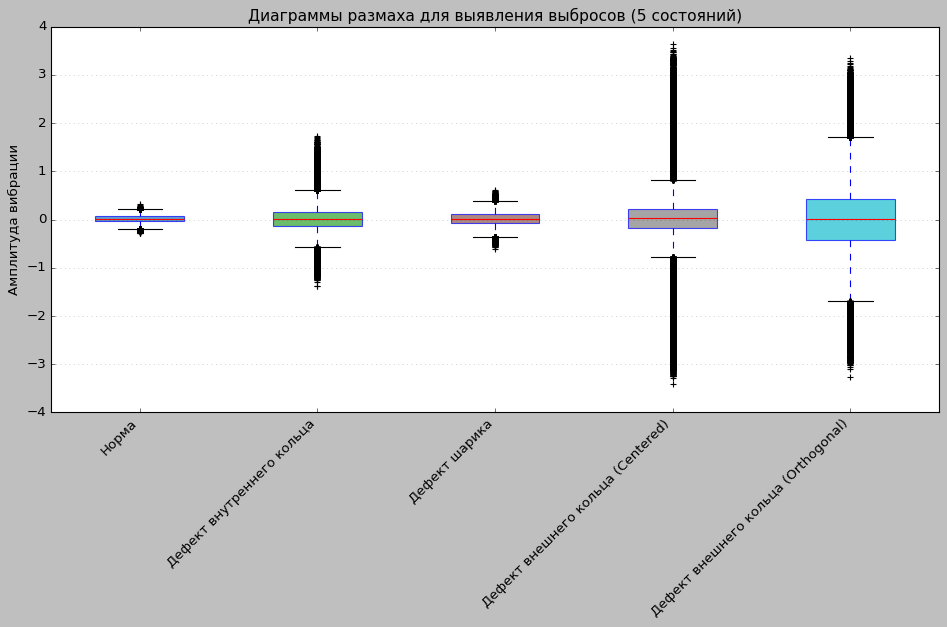


4. ФРАГМЕНТЫ СИГНАЛОВ С ВЫБРОСАМИ (первые 0.1 секунды)
----------------------------------------


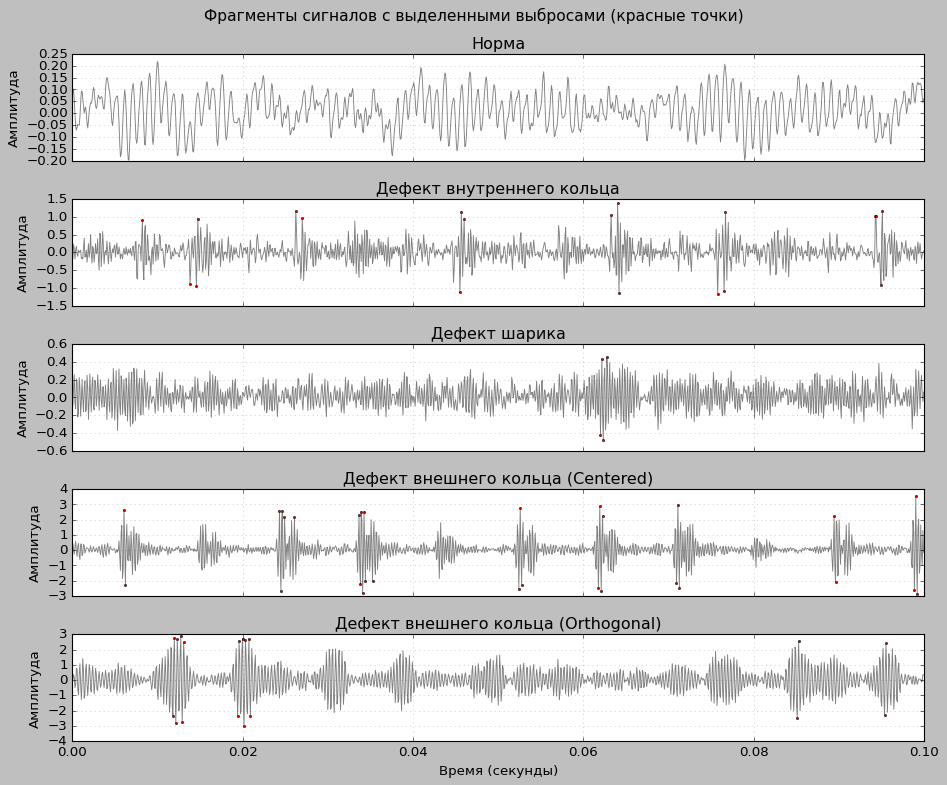

In [ ]:
# Этап 4. Анализ пропусков и выбросов

import numpy as np
import matplotlib.pyplot as plt

# 1. Проверка пропущенных значений
print("\n1. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ (NaN)")
for name, sig in zip(classes, signals):
    nan_count = np.isnan(sig).sum()
    nan_percent = nan_count / len(sig) * 100
    print(f"{name}:")
    print(f"   Пропусков: {nan_count} из {len(sig)} ({nan_percent:.4f}%)")
    if nan_count == 0:
        print(" Пропуски отсутствуют.")

# 2. Выбросы по правилу трех сигм
print("\n2. ВЫБРОСЫ ПО ПРАВИЛУ ТРЁХ СИГМ")
outliers_stats = []

for name, sig in zip(classes, signals):
    mean = np.mean(sig)
    std = np.std(sig)
    lower = mean - 3 * std
    upper = mean + 3 * std
    outliers = sig[(sig < lower) | (sig > upper)]
    count_out = len(outliers)
    percent_out = count_out / len(sig) * 100
    outliers_stats.append((name, count_out, percent_out, lower, upper))
    print(f"{name}:")
    print(f"   Границы: [{lower:.4f}, {upper:.4f}]")
    print(f"   Выбросов: {count_out} ({percent_out:.3f}%)")
    if percent_out < 1:
        print(" Доля выбросов незначительна.")
    else:
        print(" Имеется значительное количество выбросов (характерно для дефектов).")

# 3. Визуализация: диаграммы размаха (boxplot) всех каналов
print("\n3. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)")
plt.figure(figsize=(12, 8))
data_to_plot = signals
labels = classes

bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=False, vert=True)

# Раскрашиваем ящики
colors = plt.cm.tab10(np.linspace(0, 1, len(signals)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Диаграммы размаха для выявления выбросов (5 состояний)', fontsize=14)
plt.ylabel('Амплитуда вибрации')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Детальная визуализация выбросов на временных рядах
print("\n4. ФРАГМЕНТЫ СИГНАЛОВ С ВЫБРОСАМИ (первые 0.1 секунды)")
fs = 12000
samples_short = 1200  # 0.1 секунды

fig, axes = plt.subplots(5, 1, sharex=True, figsize=(12, 10))
fig.suptitle('Фрагменты сигналов с выделенными выбросами (красные точки)', fontsize=14)

for i, (name, sig) in enumerate(zip(classes, signals)):
    mean = np.mean(sig)
    std = np.std(sig)
    lower = mean - 3 * std
    upper = mean + 3 * std
    time = np.arange(min(samples_short, len(sig))) / fs
    axes[i].plot(time, sig[:samples_short], linewidth=0.8, color='gray')
    outliers_mask = (sig[:samples_short] < lower) | (sig[:samples_short] > upper)
    axes[i].plot(time[outliers_mask], sig[:samples_short][outliers_mask], 'ro', markersize=2)
    axes[i].set_ylabel('Амплитуда')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Время (секунды)')
plt.tight_layout()
plt.show()


ЭТАП 5. АНАЛИЗ ДИАПАЗОНОВ ЗНАЧЕНИЙ

ТАБЛИЦА 2. ДИАПАЗОНЫ ЗНАЧЕНИЙ СИГНАЛОВ
                          Состояние  Минимум  Максимум  Размах  Ст. отклонение
                              Норма  -0.2866    0.3113  0.5979          0.0727
          Дефект внутреннего кольца  -1.3799    1.7390  3.1189          0.2912
                      Дефект шарика  -0.6070    0.6039  1.2110          0.1387
  Дефект внешнего кольца (Centered)  -3.4087    3.6304  7.0391          0.6691
Дефект внешнего кольца (Orthogonal)  -3.2601    3.3490  6.6091          0.7694

Соотношение размахов (max/min): 11.77 раза
Соотношение стандартных отклонений: 10.58 раза


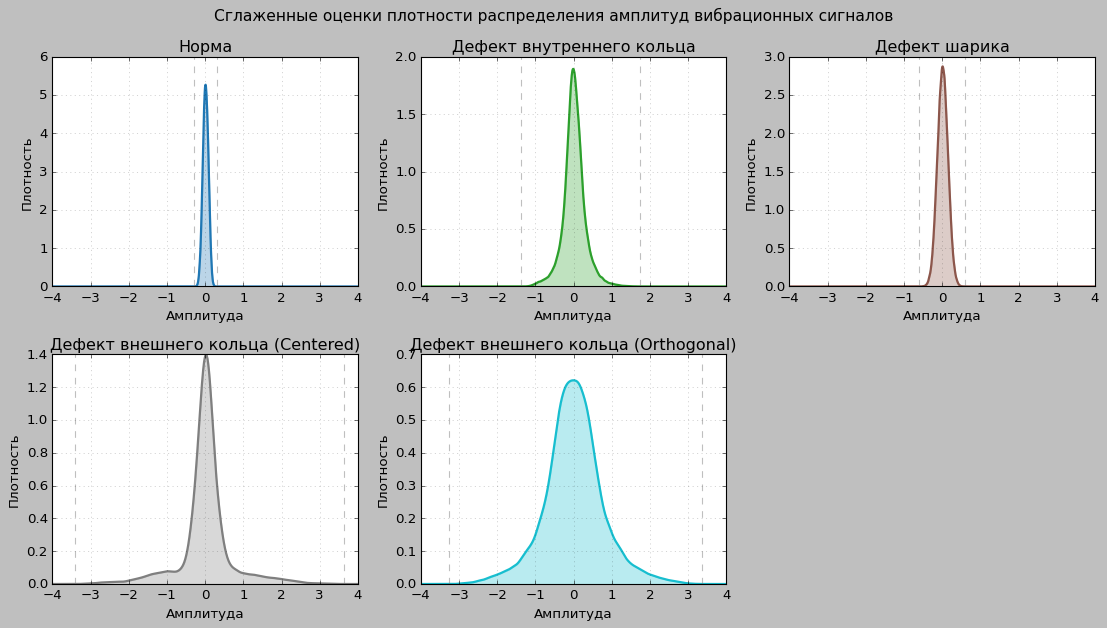

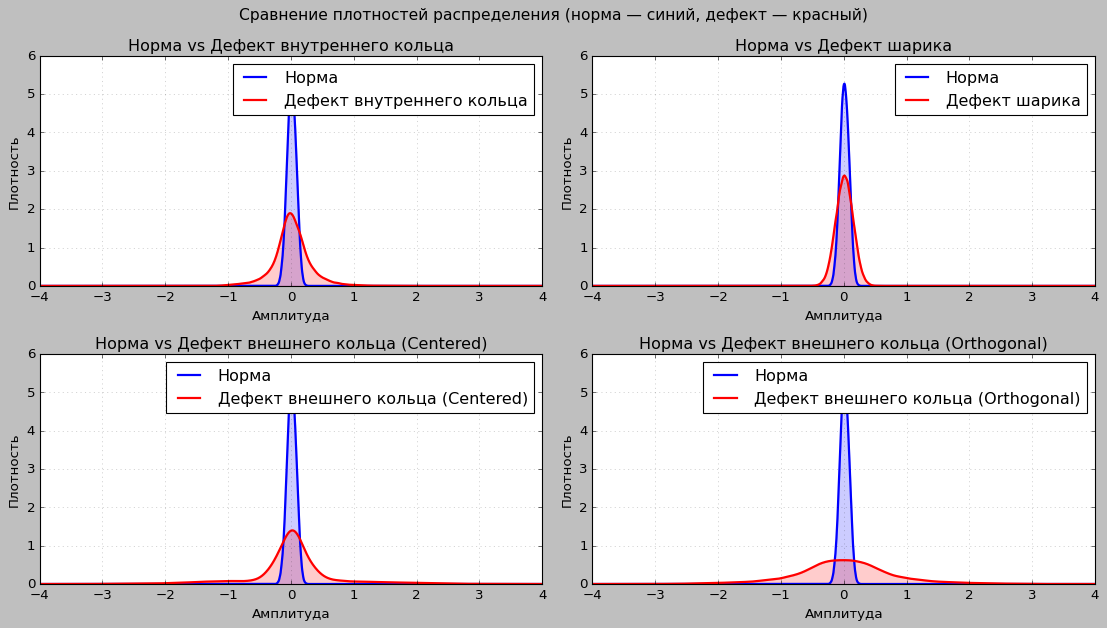


✅ Этап 5 завершён. Рекомендуется стандартизация (StandardScaler) из-за сильного различия масштабов.


In [ ]:
# Этап 5. Анализ диапазонов значений

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# 1. Таблица со статистиками (min, max, размах, std)
stats_data = []
for name, sig in zip(classes, signals):
    stats_data.append({
        'Состояние': name,
        'Минимум': np.min(sig),
        'Максимум': np.max(sig),
        'Размах': np.max(sig) - np.min(sig),
        'Ст. отклонение': np.std(sig)
    })

df_stats = pd.DataFrame(stats_data)
print("\nТАБЛИЦА 2. ДИАПАЗОНЫ ЗНАЧЕНИЙ СИГНАЛОВ")
print(df_stats.round(4).to_string(index=False))

# Соотношения
max_range = df_stats['Размах'].max()
min_range = df_stats['Размах'].min()
max_std = df_stats['Ст. отклонение'].max()
min_std = df_stats['Ст. отклонение'].min()
print(f"\nСоотношение размахов (max/min): {max_range/min_range:.2f} раза")
print(f"Соотношение стандартных отклонений: {max_std/min_std:.2f} раза")

# 2. Построение кривых плотности на отдельных подграфиках
x_vals = np.linspace(-4, 4, 1000)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(signals)))

for i, (name, sig, color) in enumerate(zip(classes, signals, colors)):
    kde = gaussian_kde(sig)
    density = kde(x_vals)
    axes[i].plot(x_vals, density, color=color, linewidth=2)
    axes[i].fill_between(x_vals, density, alpha=0.3, color=color)
    axes[i].set_title(name)
    axes[i].set_xlabel('Амплитуда')
    axes[i].set_ylabel('Плотность')
    axes[i].grid(alpha=0.3)
    axes[i].axvline(np.min(sig), color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(np.max(sig), color='gray', linestyle='--', alpha=0.5)

if len(signals) < 6:
    fig.delaxes(axes[-1])

plt.suptitle('Сглаженные оценки плотности распределения амплитуд вибрационных сигналов', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Дополнительно: наложенные KDE для сравнения с нормой (4 графика)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8))
axes2 = axes2.flatten()

normal_sig = signals[0]
normal_name = classes[0]
x_vals2 = np.linspace(-4, 4, 1000)
kde_norm = gaussian_kde(normal_sig)
density_norm = kde_norm(x_vals2)

for i, (name, sig) in enumerate(zip(classes[1:], signals[1:])):
    kde_def = gaussian_kde(sig)
    density_def = kde_def(x_vals2)
    axes2[i].plot(x_vals2, density_norm, color='blue', linewidth=2, label=normal_name)
    axes2[i].plot(x_vals2, density_def, color='red', linewidth=2, label=name)
    axes2[i].fill_between(x_vals2, density_norm, alpha=0.2, color='blue')
    axes2[i].fill_between(x_vals2, density_def, alpha=0.2, color='red')
    axes2[i].set_title(f'{normal_name} vs {name}')
    axes2[i].set_xlabel('Амплитуда')
    axes2[i].set_ylabel('Плотность')
    axes2[i].legend()
    axes2[i].grid(alpha=0.3)

plt.suptitle('Сравнение плотностей распределения (норма — синий, дефект — красный)', fontsize=14)
plt.tight_layout()
plt.show()

ЭТАП 6. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
Минимальная длина сигнала: 121265 отсчётов
Все сигналы обрезаны до этой длины для корректного расчёта корреляции.

МАТРИЦА КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ ПИРСОНА (5x5):
                                      Норма  Дефект внутреннего кольца  Дефект шарика  Дефект внешнего кольца (Centered)  Дефект внешнего кольца (Orthogonal)
Норма                                1.0000                     0.0018        -0.0014                            -0.0004                               0.0005
Дефект внутреннего кольца            0.0018                     1.0000         0.0028                            -0.0034                              -0.0066
Дефект шарика                       -0.0014                     0.0028         1.0000                             0.0008                              -0.0048
Дефект внешнего кольца (Centered)   -0.0004                    -0.0034         0.0008                             1.0000                               0.0026
Дефект внешнего к

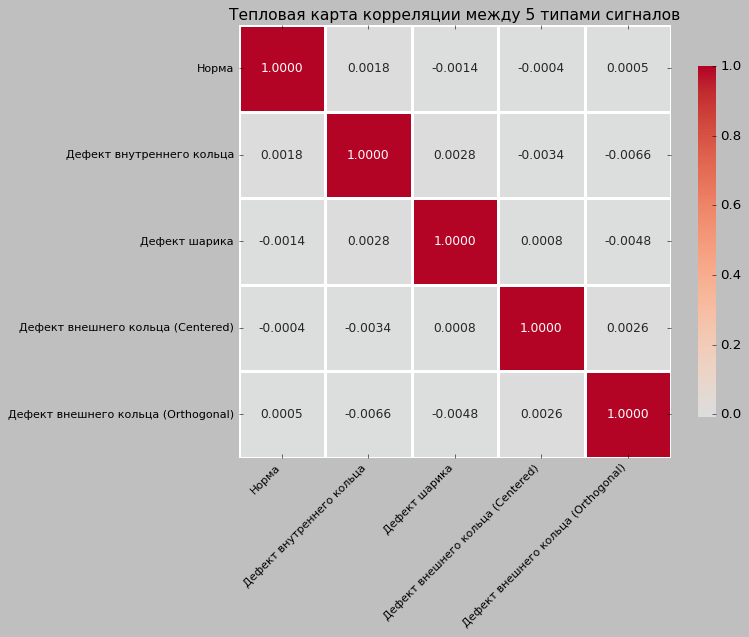


НАИБОЛЕЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ (по модулю):
  Дефект внутреннего кольца — Дефект внешнего кольца (Orthogonal): -0.0066 (отрицательная, слабая)
  Дефект шарика — Дефект внешнего кольца (Orthogonal): -0.0048 (отрицательная, слабая)
  Дефект внутреннего кольца — Дефект внешнего кольца (Centered): -0.0034 (отрицательная, слабая)
  Дефект внутреннего кольца — Дефект шарика: 0.0028 (положительная, слабая)
  Дефект внешнего кольца (Centered) — Дефект внешнего кольца (Orthogonal): 0.0026 (положительная, слабая)

ВЫВОД ПО КОРРЕЛЯЦИОННОМУ АНАЛИЗУ:
Ни одна пара каналов не имеет корреляции выше 0.9.
Дублирование информации незначительно, все каналы информативны.


In [ ]:
# Этап 6. Корреляционный анализ

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Подготовка данных: выравнивание всех сигналов до минимальной длины

min_len = min(len(sig) for sig in signals)
print(f"Минимальная длина сигнала: {min_len} отсчётов")
print("Все сигналы обрезаны до этой длины для корректного расчёта корреляции.\n")

signals_aligned = [sig[:min_len] for sig in signals]
df_corr = pd.DataFrame({name: sig for name, sig in zip(classes, signals_aligned)})

# 2. Расчёт матрицы корреляции Пирсона
corr_matrix = df_corr.corr(method='pearson')

# Вывод матрицы в виде красивой таблицы в консоль
print("МАТРИЦА КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ ПИРСОНА (5x5):")
print("="*60)
print(corr_matrix.round(4).to_string())

# 3. Тепловая карта с улучшенной читаемостью
plt.figure(figsize=(10, 8))  # Увеличили размер
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.4f', square=True, linewidths=1,
            annot_kws={'size': 11},  # Увеличили шрифт аннотаций
            cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляции между 5 типами сигналов', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Повернули подписи
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


# 4. Наиболее коррелирующие пары
pairs = []
for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        pairs.append((classes[i], classes[j], corr_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

print("\nНАИБОЛЕЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ (по модулю):")
print("="*60)
for a, b, val in pairs_sorted[:5]:
    direction = "положительная" if val > 0 else "отрицательная"
    strength = "очень сильная" if abs(val) >= 0.7 else "сильная" if abs(val) >= 0.5 else "умеренная" if abs(val) >= 0.3 else "слабая"
    print(f"  {a} — {b}: {val:.4f} ({direction}, {strength})")


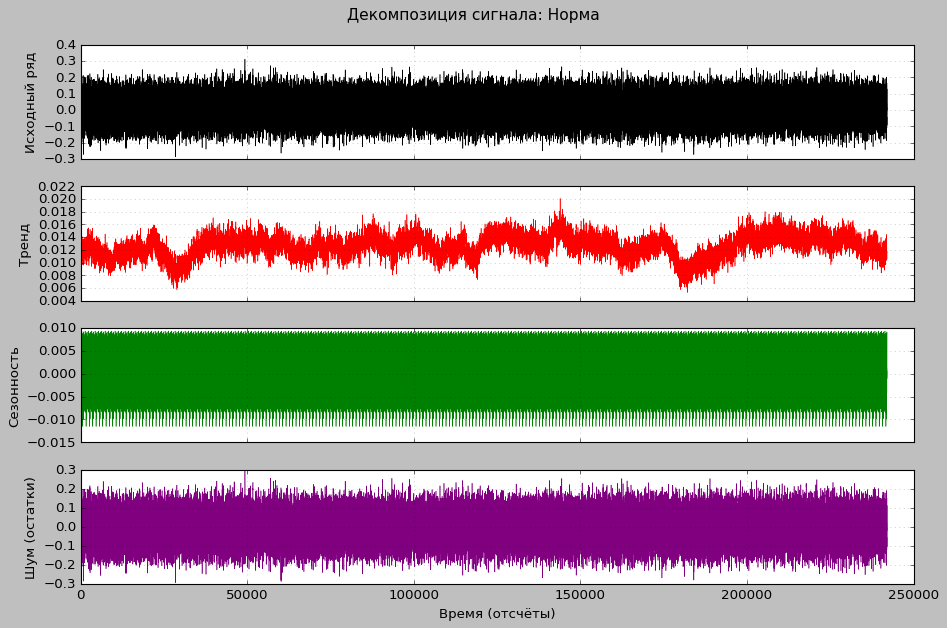

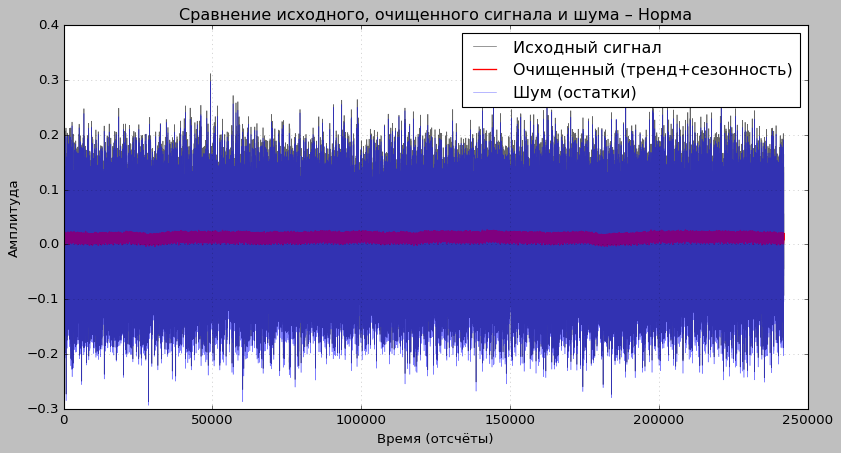

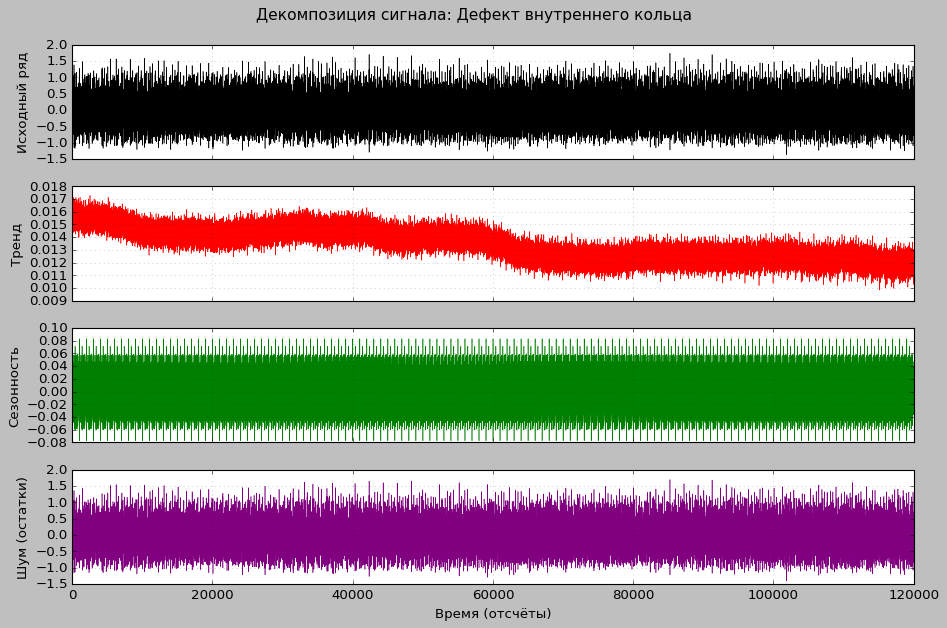

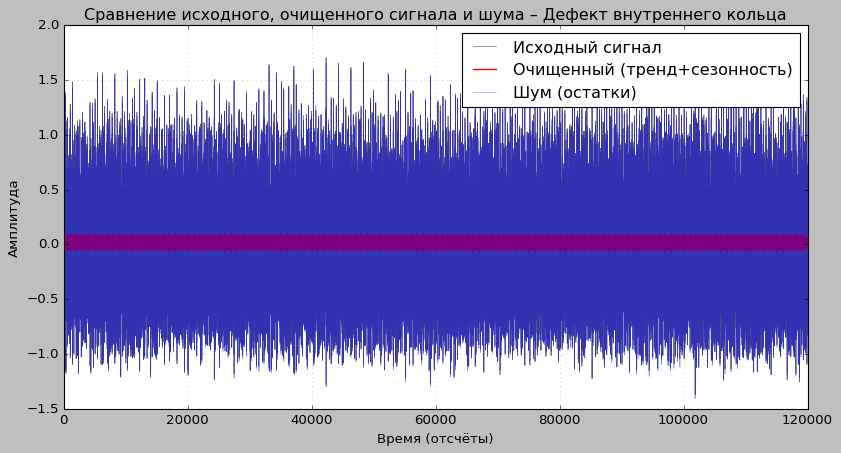

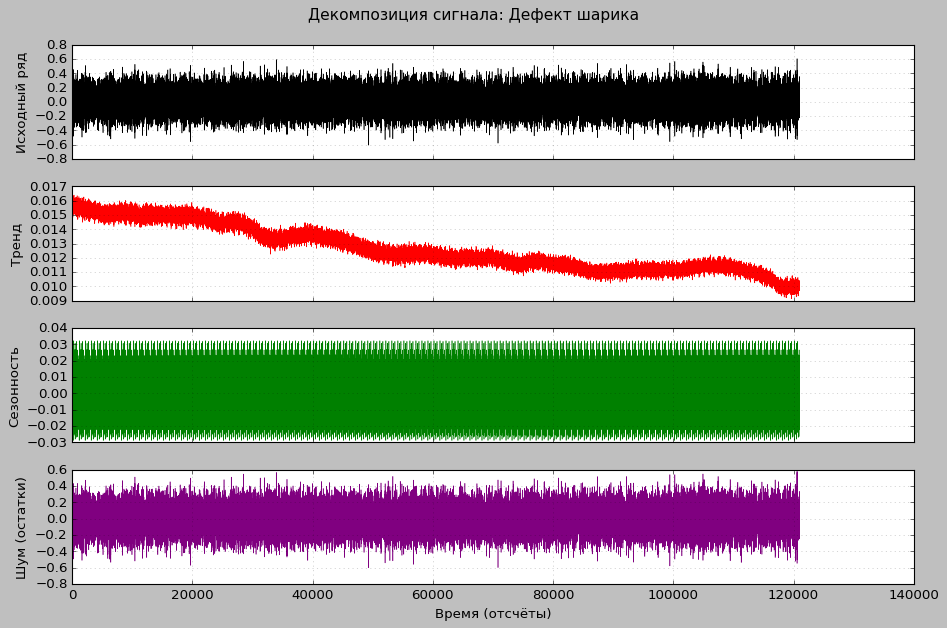

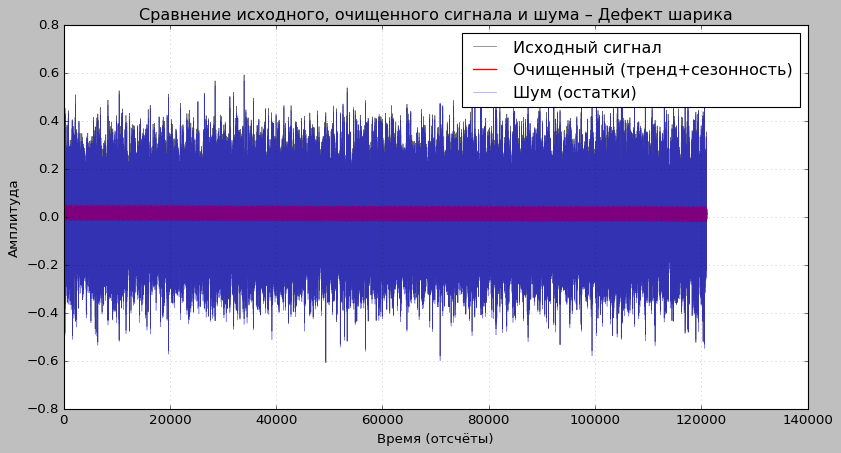

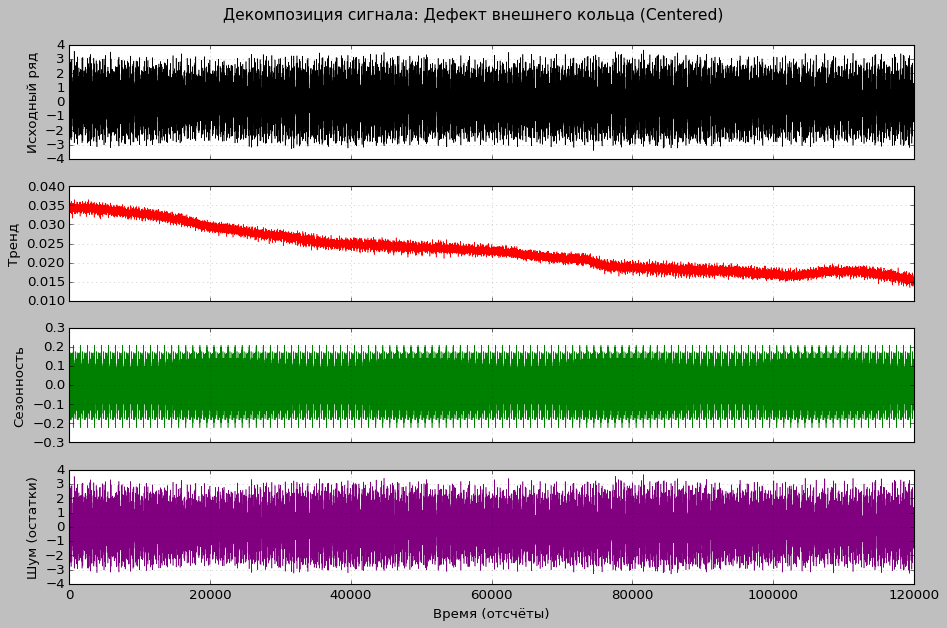

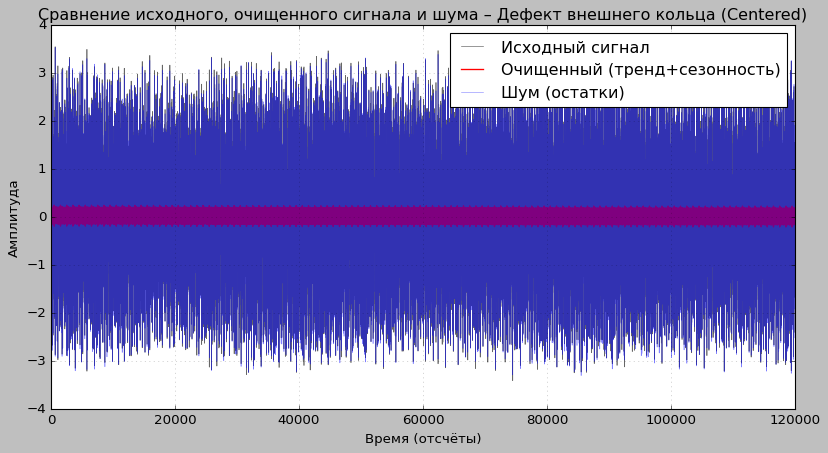

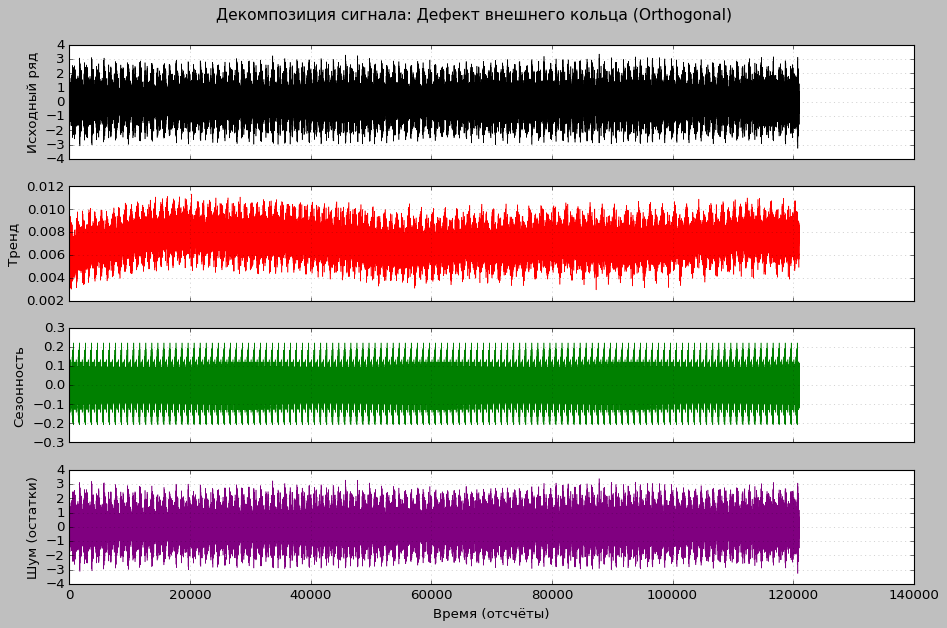

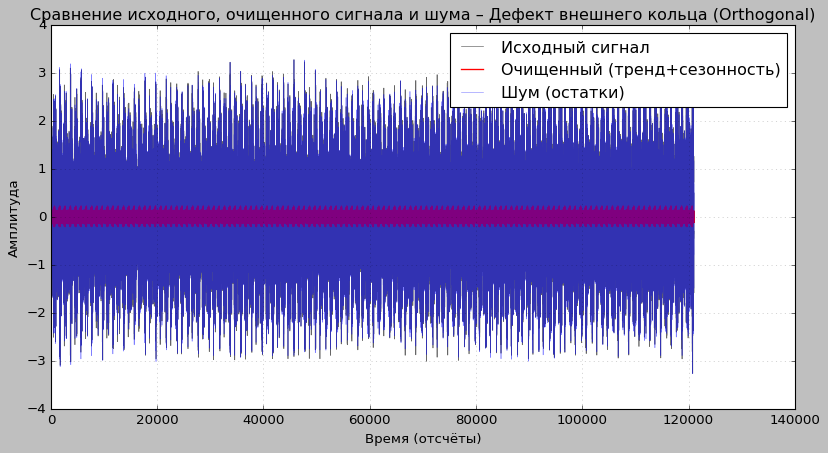


СВОДНЫЕ РЕЗУЛЬТАТЫ ДЕКОМПОЗИЦИИ И ШУМОВОГО АНАЛИЗА
                             Сигнал              Тренд                     Сезонность  SNR (дБ)                Форма шума
                              Норма падение, умеренный период 1000, амплитуда высокая    -24.13 нормальное (симметричное)
          Дефект внутреннего кольца падение, умеренный период 1000, амплитуда высокая    -21.51       с тяжелыми хвостами
                      Дефект шарика падение, умеренный период 1000, амплитуда высокая    -22.03 нормальное (симметричное)
  Дефект внешнего кольца (Centered) падение, умеренный период 1000, амплитуда высокая    -19.08       с тяжелыми хвостами
Дефект внешнего кольца (Orthogonal)    рост, умеренный период 1000, амплитуда высокая    -21.02       с тяжелыми хвостами

РЕКОМЕНДАЦИИ ПО ФИЛЬТРАЦИИ
Норма: SNR = -24.13 дБ → Обязательна серьёзная фильтрация (например, вейвлет-фильтрация)
Дефект внутреннего кольца: SNR = -21.51 дБ → Обязательна серьёзная фильтрация (например, вейвлет-фи

In [ ]:
# Этап 7. Поиск и анализ шумов

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import skew, kurtosis

period = 1000
model = 'additive'

def analyze_signal(signal, name):
    length = len(signal)
    usable = (length // period) * period
    sig = signal[:usable]
    decomp = seasonal_decompose(sig, model=model, period=period)

    trend = decomp.trend
    seas = decomp.seasonal
    resid = decomp.resid
    valid = ~(np.isnan(trend) | np.isnan(seas) | np.isnan(resid))
    trend_clean = trend[valid]
    seas_clean = seas[valid]
    resid_clean = resid[valid]
    observed_clean = sig[valid]

    # Очищенный сигнал (тренд + сезонность)
    signal_clean = trend_clean + seas_clean
    noise = resid_clean

    # Дисперсии и SNR
    var_signal = np.var(signal_clean)
    var_noise = np.var(noise)
    snr = 10 * np.log10(var_signal / var_noise) if var_noise > 0 else np.inf

    # Тренд
    trend_diff = trend_clean[-1] - trend_clean[0]
    if abs(trend_diff) < 0.01 * np.std(signal_clean):
        trend_dir = "стабильный"
        trend_intensity = "слабый"
    elif trend_diff > 0:
        trend_dir = "рост"
        trend_intensity = "умеренный" if abs(trend_diff) < 0.1 else "сильный"
    else:
        trend_dir = "падение"
        trend_intensity = "умеренный" if abs(trend_diff) < 0.1 else "сильный"

    # Сезонность
    seas_amp = (np.max(seas_clean) - np.min(seas_clean)) / 2
    if seas_amp < 0.01 * np.std(signal_clean):
        seas_amp_level = "низкая"
    elif seas_amp < 0.1 * np.std(signal_clean):
        seas_amp_level = "средняя"
    else:
        seas_amp_level = "высокая"

    # Форма шума
    skewness = skew(noise)
    kurt_val = kurtosis(noise)
    if abs(skewness) < 0.5 and abs(kurt_val) < 0.5:
        noise_shape = "нормальное (симметричное)"
    elif abs(skewness) > 1:
        noise_shape = "асимметричное"
    elif kurt_val > 1:
        noise_shape = "с тяжелыми хвостами"
    else:
        noise_shape = "близкое к нормальному"

    # График декомпозиции
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f'Декомпозиция сигнала: {name}', fontsize=14)
    axes[0].plot(observed_clean, linewidth=0.5, color='black')
    axes[0].set_ylabel('Исходный ряд')
    axes[0].grid(alpha=0.3)
    axes[1].plot(trend_clean, linewidth=0.5, color='red')
    axes[1].set_ylabel('Тренд')
    axes[1].grid(alpha=0.3)
    axes[2].plot(seas_clean, linewidth=0.5, color='green')
    axes[2].set_ylabel('Сезонность')
    axes[2].grid(alpha=0.3)
    axes[3].plot(noise, linewidth=0.5, color='purple')
    axes[3].set_ylabel('Шум (остатки)')
    axes[3].set_xlabel('Время (отсчёты)')
    axes[3].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # График сравнения исходного, очищенного сигнала и шума
    plt.figure(figsize=(12, 6))
    plt.plot(observed_clean, label='Исходный сигнал', linewidth=0.6, color='black', alpha=0.6)
    plt.plot(signal_clean, label='Очищенный (тренд+сезонность)', linewidth=1.2, color='red')
    plt.plot(noise, label='Шум (остатки)', linewidth=0.5, color='blue', alpha=0.5)
    plt.title(f'Сравнение исходного, очищенного сигнала и шума – {name}')
    plt.xlabel('Время (отсчёты)')
    plt.ylabel('Амплитуда')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        'Сигнал': name,
        'Тренд': f"{trend_dir}, {trend_intensity}",
        'Сезонность': f"период {period}, амплитуда {seas_amp_level}",
        'SNR (дБ)': round(snr, 2),
        'Форма шума': noise_shape,
    }

# Анализ всех сигналов
results = []
for sig, name in zip(signals, classes):
    results.append(analyze_signal(sig, name))

# Сводная таблица
df_results = pd.DataFrame(results)
print("СВОДНЫЕ РЕЗУЛЬТАТЫ ДЕКОМПОЗИЦИИ И ШУМОВОГО АНАЛИЗА")
print(df_results.to_string(index=False))

# Рекомендации по фильтрации
print("РЕКОМЕНДАЦИИ ПО ФИЛЬТРАЦИИ")
for _, row in df_results.iterrows():
    snr = row['SNR (дБ)']
    if snr > 20:
        rec = "Фильтрация не требуется"
    elif snr > 10:
        rec = "Фильтрация не обязательна, можно применить медианный фильтр"
    elif snr > 0:
        rec = "Желательна фильтрация (скользящее среднее или медианный фильтр)"
    else:
        rec = "Обязательна серьёзная фильтрация (например, вейвлет-фильтрация)"
    print(f"{row['Сигнал']}: SNR = {snr:.2f} дБ → {rec}")
